In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from house_data import load_house_data
from lab_utils_common import dlc
np.set_printoptions(precision=2)

import pandas as pd

In [17]:
X_train, y_train = load_house_data()
X_features = ['size(sqft)','bedrooms','floors','age']

In [24]:
df = pd.DataFrame(X_train, columns=X_features)
print(df.head())
print(df.shape)

   size(sqft)  bedrooms  floors   age
0      1244.0       3.0     1.0  64.0
1      1947.0       3.0     2.0  17.0
2      1725.0       3.0     2.0  42.0
3      1959.0       3.0     2.0  15.0
4      1314.0       2.0     1.0  14.0
(99, 4)


In [25]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

print(X_norm[:5,:])

Peak to Peak range by column in Raw        X:[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized X:[5.85 6.14 2.06 3.69]
[[-0.42  0.43 -0.79  0.99]
 [ 1.28  0.43  1.27 -0.83]
 [ 0.74  0.43  1.27  0.14]
 [ 1.31  0.43  1.27 -0.91]
 [-0.25 -1.1  -0.79 -0.95]]


In [26]:
#create and fit regression model
sgdr = SGDRegressor(max_iter = 1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(sgdr.n_iter_)

SGDRegressor()
108


In [27]:
# View Parameters
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
print( "model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16")

model parameters:                   w: [109.83 -20.94 -32.32 -38.09], b:[363.16]
model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16


In [29]:
# Make predictions
y_pred_sgd = sgdr.predict(X_norm)
y_pred = np.dot(X_norm, w_norm) + b_norm

print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[295.2  485.78 389.6  491.94]
Target values 
[300.  509.8 394.  540. ]


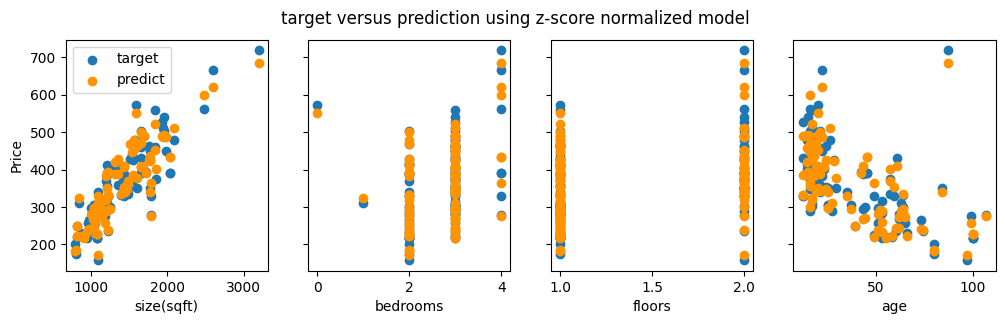

In [30]:
# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],y_pred,color=dlc["dlorange"], label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()